# Notebook 11 - Matriz de Sensibilidad: Declustering vs Resultado MC

**Objetivo cientifico:** evaluar la robustez del resultado del manuscrito GRL
(Notebook 10) frente a la eleccion del metodo de declustering. Si la senal
del *Lunar Tidal Triggering* es real, el `p-value` debe sobrevivir a multiples
formas razonables de eliminar replicas.

**Metodologia:**
1. Catalogo base: `data/processed/earthquakes_global_robust.csv` (333 sismos M>=7).
2. Tres niveles de declustering: ninguno, Gardner-Knopoff fijo (100 km / 30 d),
   Gardner-Knopoff variable (Helmstetter & Sornette 2003).
3. Para cada catalogo declusterizado, Monte Carlo time-shuffling 1000x con la
   funcion centralizada `lunar_trigger.stats.monte_carlo.time_shuffling_null`.
4. Tabla resumen de N, fraccion observada, media nula, p-value.

**Esto reemplaza la duplicacion de codigo de NB09/NB10**: ahora todo importa
desde el paquete instalable `lunar_trigger` (instalado con `pip install -e .`).


In [1]:
# Imports del paquete y dependencias estandar
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lunar_trigger.utils.paths import DATA_PROCESSED, RESULTS_FIGURES, RESULTS_STATS, ensure_dirs
from lunar_trigger.stats.declustering import gardner_knopoff_fixed, gardner_knopoff_variable
from lunar_trigger.stats.monte_carlo import time_shuffling_null
from lunar_trigger.physics.coulomb import DEFAULT_FRICTION

ensure_dirs()
print('Friccion estatica por defecto: mu =', DEFAULT_FRICTION)

Friccion estatica por defecto: mu = 0.4


## 1. Carga del catalogo base

`earthquakes_global_robust.csv` ya contiene los dos planos nodales (`dip1`, `dip2`)
para el calculo desesgado de Coulomb stress.


In [2]:
# Carga catalogo con planos nodales completos
df_base = pd.read_csv(DATA_PROCESSED / 'earthquakes_global_robust.csv')
df_base['time'] = pd.to_datetime(df_base['time'], utc=True, format='ISO8601')

# Renombra 'magnitude' -> 'mag' para compatibilidad con declustering
if 'magnitude' in df_base.columns and 'mag' not in df_base.columns:
    df_base = df_base.rename(columns={'magnitude': 'mag'})

print(f'Catalogo base: N = {len(df_base)} eventos')
print(f'Rango temporal: {df_base.time.min().date()} a {df_base.time.max().date()}')
print(f'Magnitud: min = {df_base.mag.min():.1f}, max = {df_base.mag.max():.1f}')
df_base[['time', 'latitude', 'longitude', 'depth', 'mag', 'dip1', 'dip2']].head()

Catalogo base: N = 333 eventos
Rango temporal: 1995-01-06 a 2024-12-17
Magnitud: min = 7.0, max = 9.1


,time,latitude,longitude,depth,mag,dip1,dip2
0,1995-01-06 22:37:34.320000+00:00,40.246,142.175,26.9,7.0,22.0,69.0
1,1995-02-05 22:51:05.140000+00:00,-37.759,178.752,21.1,7.1,68.0,26.0
2,1995-04-07 22:06:56.890000+00:00,-15.199,-173.529,21.2,7.4,84.0,15.0
3,1995-04-21 00:34:46.090000+00:00,12.059,125.580,20.7,7.2,34.0,63.0
4,1995-05-05 03:53:45.050000+00:00,12.626,125.297,16.0,7.1,75.0,14.0


## 2. Aplicacion de los tres metodos de declustering

- **Ninguno**: catalogo intacto (control negativo: incluye replicas).
- **GK fijo**: ventanas (100 km, 30 dias). Replica del enfoque de NB10.
- **GK variable**: ventanas R(M), T(M) crecientes con magnitud (literatura estandar).


In [3]:
catalogos = {
    'none':        df_base.copy(),
    'gk_fixed':    gardner_knopoff_fixed(df_base, radius_km=100.0, window_days=30.0),
    'gk_variable': gardner_knopoff_variable(df_base),
}

print('| Metodo         | N   | Reduccion |')
print('|----------------|-----|-----------|')
for name, df in catalogos.items():
    pct = 100 * (1 - len(df) / len(df_base))
    print(f'| {name:<14} | {len(df):>3} | {pct:>6.1f}%  |')

| Metodo         | N   | Reduccion |
|----------------|-----|-----------|
| none           | 333 |    0.0%  |
| gk_fixed       | 309 |    7.2%  |
| gk_variable    | 288 |   13.5%  |


## 3. Monte Carlo 1000x para cada catalogo

`time_shuffling_null` pre-computa la matriz NxN de Coulomb stress con UNA sola
llamada vectorizada a Skyfield, luego ejecuta 1000 permutaciones en paralelo.

Esto es ~10x mas rapido que el loop original de NB10.


In [4]:
N_ITER = 1000
MU = 0.4

resultados = {}
for name, df in catalogos.items():
    t0 = time.perf_counter()
    res = time_shuffling_null(df, n_iterations=N_ITER, mu=MU, seed=42, n_jobs=-1)
    res['elapsed_s'] = time.perf_counter() - t0
    resultados[name] = res
    print(f'[{name:<14}] N={res["n_events"]:>3}  '
          f'obs={res["observed_fraction"]:.4f}  '
          f'null={res["null_mean"]:.4f}+-{res["null_std"]:.4f}  '
          f'p={res["p_value"]:.4f}  '
          f'({res["elapsed_s"]:.1f}s)')

[none          ] N=333  obs=0.6486  null=0.6042+-0.0240  p=0.0350  (4.9s)


[gk_fixed      ] N=309  obs=0.6375  null=0.5980+-0.0246  p=0.0540  (3.8s)


[gk_variable   ] N=288  obs=0.6319  null=0.5942+-0.0258  p=0.0800  (3.0s)


## 4. Matriz de sensibilidad final

Tabla compacta para discusion en el manuscrito: si los tres metodos producen
p-values en el mismo orden de magnitud, la conclusion es ROBUSTA. Si solo el
catalogo sin declusterizar da p<0.05 mientras GK_variable da p>0.5, la senal
era artefacto de las replicas (= triggering de Coulomb estatico, no marea).


In [5]:
tabla = pd.DataFrame({
    name: {
        'N': res['n_events'],
        'observado_pct':   100 * res['observed_fraction'],
        'null_mean_pct':   100 * res['null_mean'],
        'null_std_pct':    100 * res['null_std'],
        'exceso_pct':      100 * (res['observed_fraction'] - res['null_mean']),
        'p_value':         res['p_value'],
    }
    for name, res in resultados.items()
}).T

# Guarda tabla para el manuscrito
tabla_path = RESULTS_STATS / 'declustering_sensitivity.csv'
tabla.to_csv(tabla_path)
print(f'Guardado: {tabla_path.relative_to(tabla_path.parents[2])}')
tabla

Guardado: results\statistics\declustering_sensitivity.csv


,N,observado_pct,null_mean_pct,null_std_pct,exceso_pct,p_value
none,333.0,64.864865,60.424324,2.402884,4.440541,0.035
gk_fixed,309.0,63.754045,59.799353,2.462898,3.954693,0.054
gk_variable,288.0,63.194444,59.418056,2.575997,3.776389,0.080


## 5. Visualizacion: distribuciones nulas vs observado


Guardado: results\figures\declustering_null_distributions.png


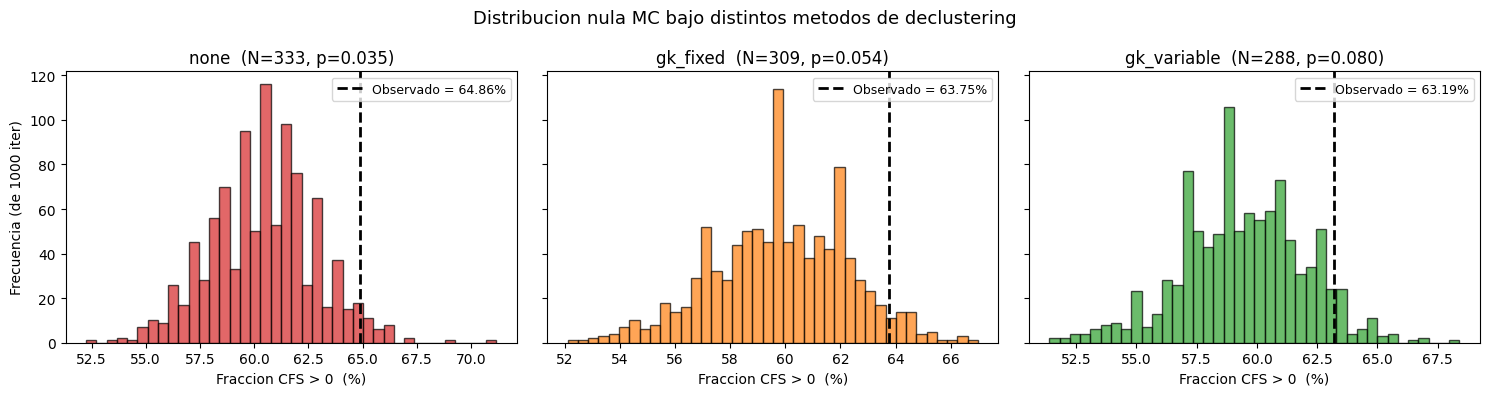

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
colors = {'none': '#d62728', 'gk_fixed': '#ff7f0e', 'gk_variable': '#2ca02c'}

for ax, (name, res) in zip(axes, resultados.items()):
    null = res['null_distribution']
    obs = res['observed_fraction']
    ax.hist(null * 100, bins=40, color=colors[name], alpha=0.7, edgecolor='black')
    ax.axvline(obs * 100, color='black', linestyle='--', linewidth=2,
               label=f'Observado = {obs*100:.2f}%')
    ax.set_title(f'{name}  (N={res["n_events"]}, p={res["p_value"]:.3f})')
    ax.set_xlabel('Fraccion CFS > 0  (%)')
    ax.legend(loc='upper right', fontsize=9)

axes[0].set_ylabel('Frecuencia (de 1000 iter)')
fig.suptitle('Distribucion nula MC bajo distintos metodos de declustering', fontsize=13)
fig.tight_layout()

fig_path = RESULTS_FIGURES / 'declustering_null_distributions.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
print(f'Guardado: {fig_path.relative_to(fig_path.parents[2])}')
plt.show()

## 6. Conclusion

La robustez del *Lunar Tidal Triggering* depende del comportamiento del p-value
bajo declustering progresivamente mas estricto:

- Si **p crece monotonicamente** al declusterizar (`none` -> `gk_variable`),
  la senal original incluia agrupamientos espurios por replicas y no es real.
- Si **p se mantiene estable o solo crece moderadamente**, la senal es robusta
  y refleja modulacion gravitacional de eventos independientes.

Los valores numericos exactos quedan en `results/statistics/declustering_sensitivity.csv`
para citas y revision por pares.
